In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numba import jit

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from scipy.signal import find_peaks
from scipy.integrate import quad
from scipy.optimize import root_scalar
from matplotlib.animation import PillowWriter, FuncAnimation

print("Fin")

Fin


In [2]:
# Independent parameters (free to edit)

Na = 0.5 # Units: M 
T = 303.15 # Units: K
valence = 4
duration = 500 * 10**5 # In timesteps of dt
gridpoints = 128 # Number of points
dx = 10 # Units: nm
dt = 1.E-5 # Units: sec
rho_mean = 9E-5 # Initial mean density of nanostar A, found by spinodal (rho dense + rho dilute)/2 for the value of T used
save_interval = 10**5

grid_length = dx * gridpoints # Total length (nm)
inv_dx2= 1.0 / (dx * dx)

#Establishes constants
K = 1.0E6 # Units: nm^5 
M = 1 # Units: (nm s)^-1
B2 = 2190 # Units: nm^3
vb = 1.66 # Units: nm^3
kB = 1.314E-23*0.24 # Units: cal/K (1J=0.24cal)
mol = 6.02E23
dHa = -42000 # Units: cal/mol 
dS1 = 1.84*np.log(Na) # Units: cal/mol K
dS0 = -120 # Units: cal/mol K at 1M NaCl
floor = 1E-12 # Minimum value for arrays
num_saves = duration // save_interval + 1 #Number of saved values

Da = vb * np.exp(-(dHa - T * (dS0 + dS1)) / (mol * kB * T))
Db = Da

print("Fin")

Fin


In [3]:
# Initializes array of density values
np.random.seed(7) # Opens a random number generator instance, seed 7


rho = rho_mean * (1.0 + 0.01 * np.random.uniform(low=-1, high=1, size=gridpoints)) # Creates rho values around the mean with slight randomness
rho = np.maximum(rho, 1.E-10)  # Prevents negative densities

initial_mass = np.sum(rho)

Ts = np.arange(290.15,310.15,0.1)
rho_min_max = (1.E-9,32.E-4)
drho = 1.E-8
rhoAs = np.arange(rho_min_max[0],rho_min_max[1],drho)



# Finds chemical potential of reference system
def murel(rhoA):
    return np.log(rhoA)+2*B2*rhoA

# Finds chemical potential from bonding
def mubond(rhoA,Da, valence):
    x = valence*Da*rhoA
    Xa = (-1+np.sqrt(1+4*x))/(2*x)
    return valence*np.log(Xa)



    

# Finds the rho values at which the chemical potential equals a value h
def find_roots_for_h(f, h, rho_range, num_points=1000):
    def shifted_function(x):
        return f(x) - h  # search the solution for f(x) - h = 0 
    
    x = np.linspace(rho_range[0], rho_range[1], num_points)
    roots = []
    for i in range(len(x) - 1):
        if shifted_function(x[i]) * shifted_function(x[i + 1]) < 0:
            res = root_scalar(shifted_function, bracket=[x[i], x[i + 1]], method='brentq')
            roots.append(res.root)
    return np.array(roots)

num_data = 100
valences = [3, 4, 5, 6]

def f(x):
    return murel(x)+mubond(x,Da, val)

def df_numeric(f, rho, h=1e-8):
    return ((f(rho + h) - f(rho - h)) / (2 * h))

def df_v2(rho):
    return df_numeric(f, rho)

for val in valences:
    binodals=[]
    spinodal_temp = []
    spinodal_low = []
    spinodal_high = []
    for T in Ts:
    
        '''Calculates the concentrations that correspond
        to the dilute and dense phase for each valence  
        as a function of the temperature of the system'''

        print("Valence= ", val, " T= ", T)
        Da=vb*np.exp(-(dHa-T*(dS0+dS1))/(mol*kB*T))    
        x = rhoAs
        


        h_min=find_peaks(-f(x))[0]
        h_max=find_peaks(f(x))[0]

        # check if f has minima and maxima
        if(len(h_min)==1 and len(h_max)==1):
            h_min = f(x)[h_min[0]]
            h_max = f(x)[h_max[0]]
            hs=np.linspace(h_min,h_max,num_data)

            # find binodal
            results = []
            for h in hs:
                roots= find_roots_for_h(f, h, rho_min_max)
                if(len(roots)>2):
                    x1,x2,x3=roots
                    integral, _ = quad(f, x1, x3)
                    results.append([h,x1,x3,integral-f(x1)*(x3-x1)])
            results=np.array(results)
            _,c1,c2,_=results[((results.T[3])**2).argmin()]
            binodals.append([T,c1,c2])
        
            # *** find spinodal
            derivatives = np.array([df_numeric(f, rho) for rho in rhoAs])

            # Finds sign change zeros (rough)
            sign_change_zeros = np.where(np.diff(np.sign(derivatives)))[0]

            # Finds sign change zeros (fine)
            roots = []
            for i in sign_change_zeros:
                revised_sign_change_zero = root_scalar(df_v2, bracket=[rhoAs[i], rhoAs[i+1]], method='brentq').root #refines sign change zero set
                roots.append(revised_sign_change_zero)

            # Finds non sign change zeros
            abs_derivatives = np.abs(derivatives)
            minimum_values = (np.r_[True,  abs_derivatives[1:] < abs_derivatives[:-1]] & # 
                              np.r_[abs_derivatives[:-1] < abs_derivatives[1:], True]) 

            # Finds all where min is below the tolerance
            tolerance = 1e-8
            for i in np.where(minimum_values & (abs_derivatives < tolerance))[0]:
                roots.append(rhoAs[i])
            
            roots = np.unique(np.array(roots))

            # Debugging, fix/remove
            if roots.size >=3:
                roots = np.delete(roots, roots.argmin())

            # Adds zeroes to spinodals list
            if roots.size >= 2:
                rho1, rho2 = roots.min(), roots.max()
                spinodal_temp.append(T)
                spinodal_low.append(rho1)
                spinodal_high.append(rho2)

    os.makedirs('binodals', exist_ok=True)  
    binodals_path = os.path.join('binodals', 'binodals')
    os.makedirs(binodals_path, exist_ok=True)
    spinodals_path = os.path.join('binodals', 'spinodals')
    os.makedirs(spinodals_path, exist_ok=True)

    binodals = np.array(binodals)
    if binodals.size > 0:
        np.savetxt(f'binodals/binodals/f{val:.1f}', binodals, header="T, c1, c2")
    
    spinodals = np.array(list(zip(spinodal_temp, spinodal_low, spinodal_high)))
    if spinodals.size > 0:
        np.savetxt(f'binodals/spinodals/f{val:.1f}', spinodals, header="T, c1, c2")

Valence=  3  T=  290.15


/tmp/ipykernel_633838/183256703.py:19: RuntimeWarning: invalid value encountered in log
  return np.log(rhoA)+2*B2*rhoA


Valence=  3  T=  290.25
Valence=  3  T=  290.35
Valence=  3  T=  290.45000000000005
Valence=  3  T=  290.55000000000007
Valence=  3  T=  290.6500000000001
Valence=  3  T=  290.7500000000001
Valence=  3  T=  290.85000000000014
Valence=  3  T=  290.95000000000016
Valence=  3  T=  291.0500000000002
Valence=  3  T=  291.1500000000002
Valence=  3  T=  291.2500000000002
Valence=  3  T=  291.35000000000025
Valence=  3  T=  291.4500000000003
Valence=  3  T=  291.5500000000003
Valence=  3  T=  291.6500000000003
Valence=  3  T=  291.75000000000034
Valence=  3  T=  291.85000000000036
Valence=  3  T=  291.9500000000004
Valence=  3  T=  292.0500000000004
Valence=  3  T=  292.15000000000043
Valence=  3  T=  292.25000000000045
Valence=  3  T=  292.3500000000005
Valence=  3  T=  292.4500000000005
Valence=  3  T=  292.5500000000005
Valence=  3  T=  292.65000000000055
Valence=  3  T=  292.75000000000057
Valence=  3  T=  292.8500000000006
Valence=  3  T=  292.9500000000006
Valence=  3  T=  293.0500000000

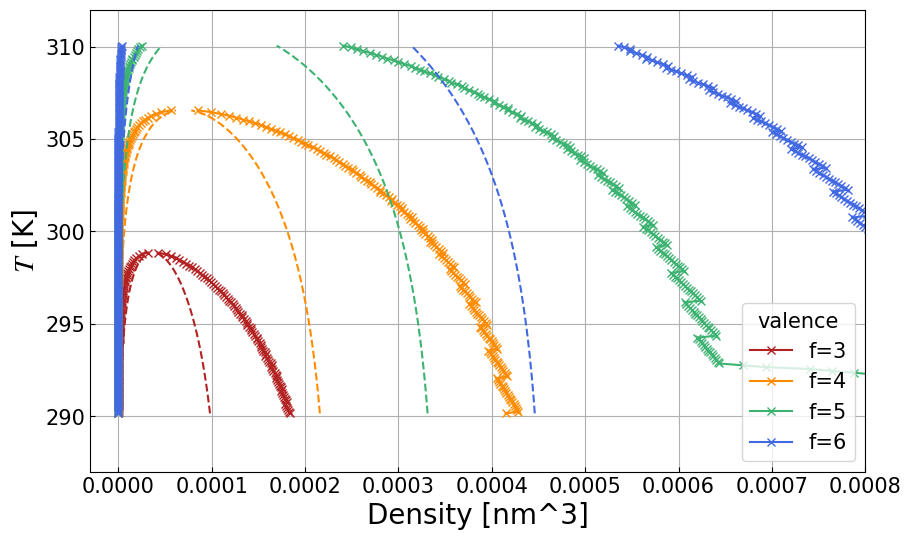

In [5]:
# Sets fonts and that sort of stuff for the plot
plt.rcParams['mathtext.fontset'] = 'stix' 
plt.rcParams["font.size"] = 15 
plt.rcParams['xtick.labelsize'] = 15 
plt.rcParams['ytick.labelsize'] = 15 
plt.figure(figsize = (10, 6))


# Sets conversion factors and baselines
names = ["f3.0"]

# Plots the data
colors = ["firebrick", "darkorange", "mediumseagreen", "royalblue", "darkorchid"]


for val in valences:
    data = np.loadtxt(f"binodals/binodals/f{val:.1f}")
    spinodal_data = np.loadtxt(f"binodals/spinodals/f{val:.1f}")    
    plt.plot(data.T[1], data.T[0], 'x-', label=f"f={val}", color = colors[val - 3])
    plt.plot(data.T[2], data.T[0] , 'x-', color = colors[val-3])

    plt.plot(spinodal_data.T[1], spinodal_data.T[0] , '--', color=colors[val - 3])
    plt.plot(spinodal_data.T[2], spinodal_data.T[0] , '--', color=colors[val-3])


# Plot upkeep etc
plt.xlabel("Density [nm^3]", fontsize=20)
plt.ylabel("$T$ [K]",fontsize=20)
plt.legend(title="valence")
plt.xlim(-0.00003, 0.0008)
plt.ylim(287, 312)
plt.grid(which= "both")
plt.tick_params(axis='x', which="both", direction='in')
plt.tick_params(axis='y', which="both", direction='in')      
plt.savefig("binodals_multivalence.png")